In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True


# Bar Charts

Useful when the input variable is categorical and the output is the frequency of each category.

In [2]:
# The flavor of ice cream is a categorical variable 
# The count of 
icecream = Table().with_columns(
    'Flavor', make_array('Chocolate', 'Strawberry', 'Vanilla'),
    'Number of Cartons', make_array(16, 5, 9)
)
icecream

Flavor,Number of Cartons
Chocolate,16
Strawberry,5
Vanilla,9


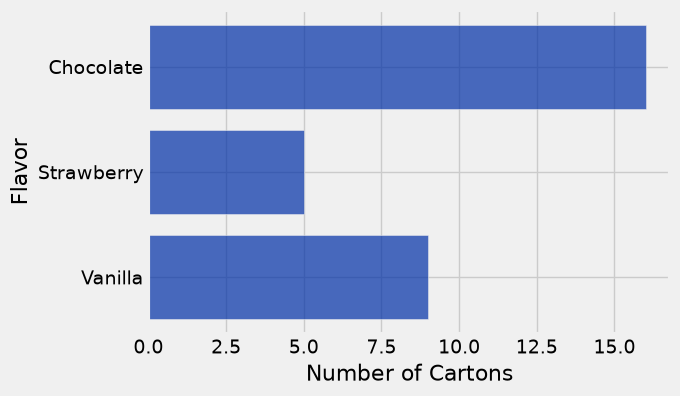

In [3]:
icecream.barh('Flavor', 'Number of Cartons')
# or simply
#icecream.barh('Flavor')

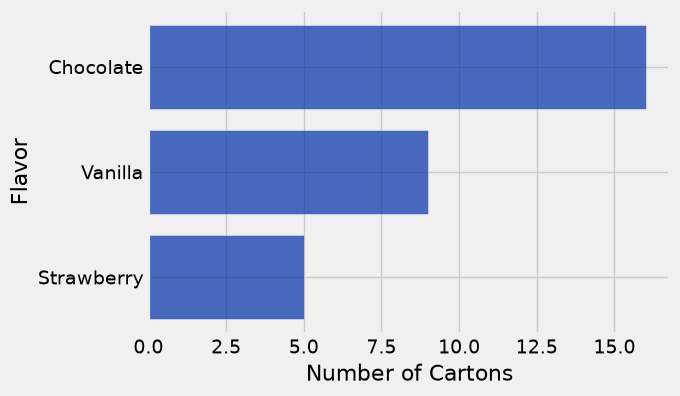

In [4]:
# Even better if you sort first
icecream = icecream.sort('Number of Cartons', descending = True)
icecream.barh('Flavor')

# Practice
Plot the ten movies with the *lowest* adjusted gross as a bar chart.
The category is the name of the movie.
The "frequencies" are the adjusted gross.

* Sort in such a way that the lowest adjusted gross is on top.
* Use take() to get the top ten rows in a new table.
* Call barh on the new table.

In [13]:
# Highest grossing movies as of 2017
top_movies = Table.read_table('top_movies_2017.csv')
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


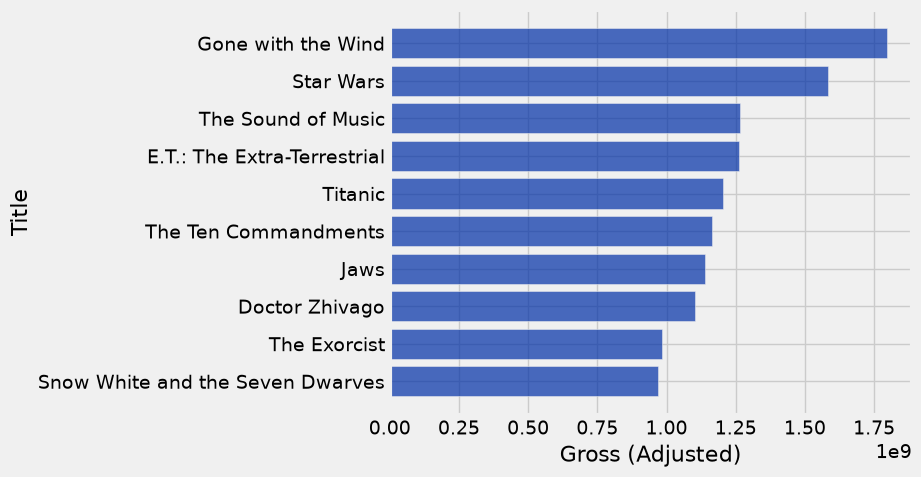

In [18]:
top_movies = top_movies.sort('Gross (Adjusted)', descending = True)
lowest_ten = top_movies.take(np.arange(10))
lowest_ten.barh('Title', 'Gross (Adjusted)')


# Grouping

In [19]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [20]:
# group counts how many times a particular category appears in your data set
studio_distribution = top_movies.group('Studio')
studio_distribution

Studio,count
AVCO,1
Buena Vista,35
Columbia,9
Disney,11
Dreamworks,3
Fox,24
IFC,1
Lionsgate,3
MGM,7
Metro,1


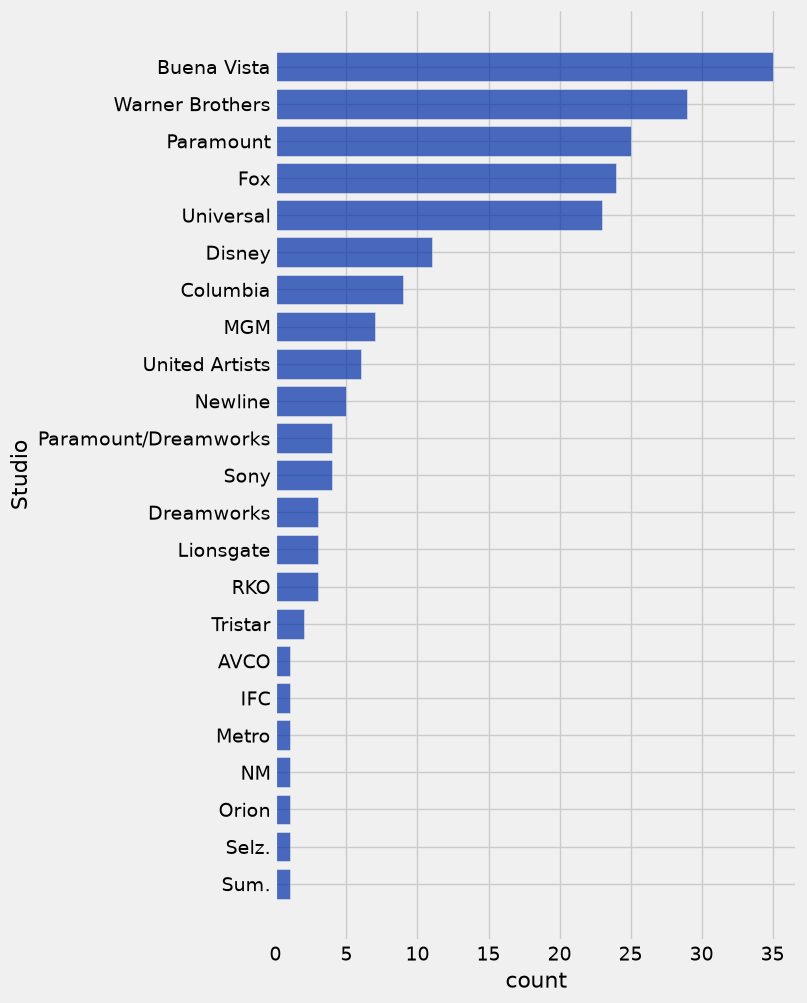

In [ ]:
# Grouped data is perfect for a bar chart.
studio_distribution = studio_distribution.sort('count', descending = True)
studio_distribution.barh('Studio', 'count')

# Practice
Group the movies in top_movies by release year and plot the resulting frequencies.

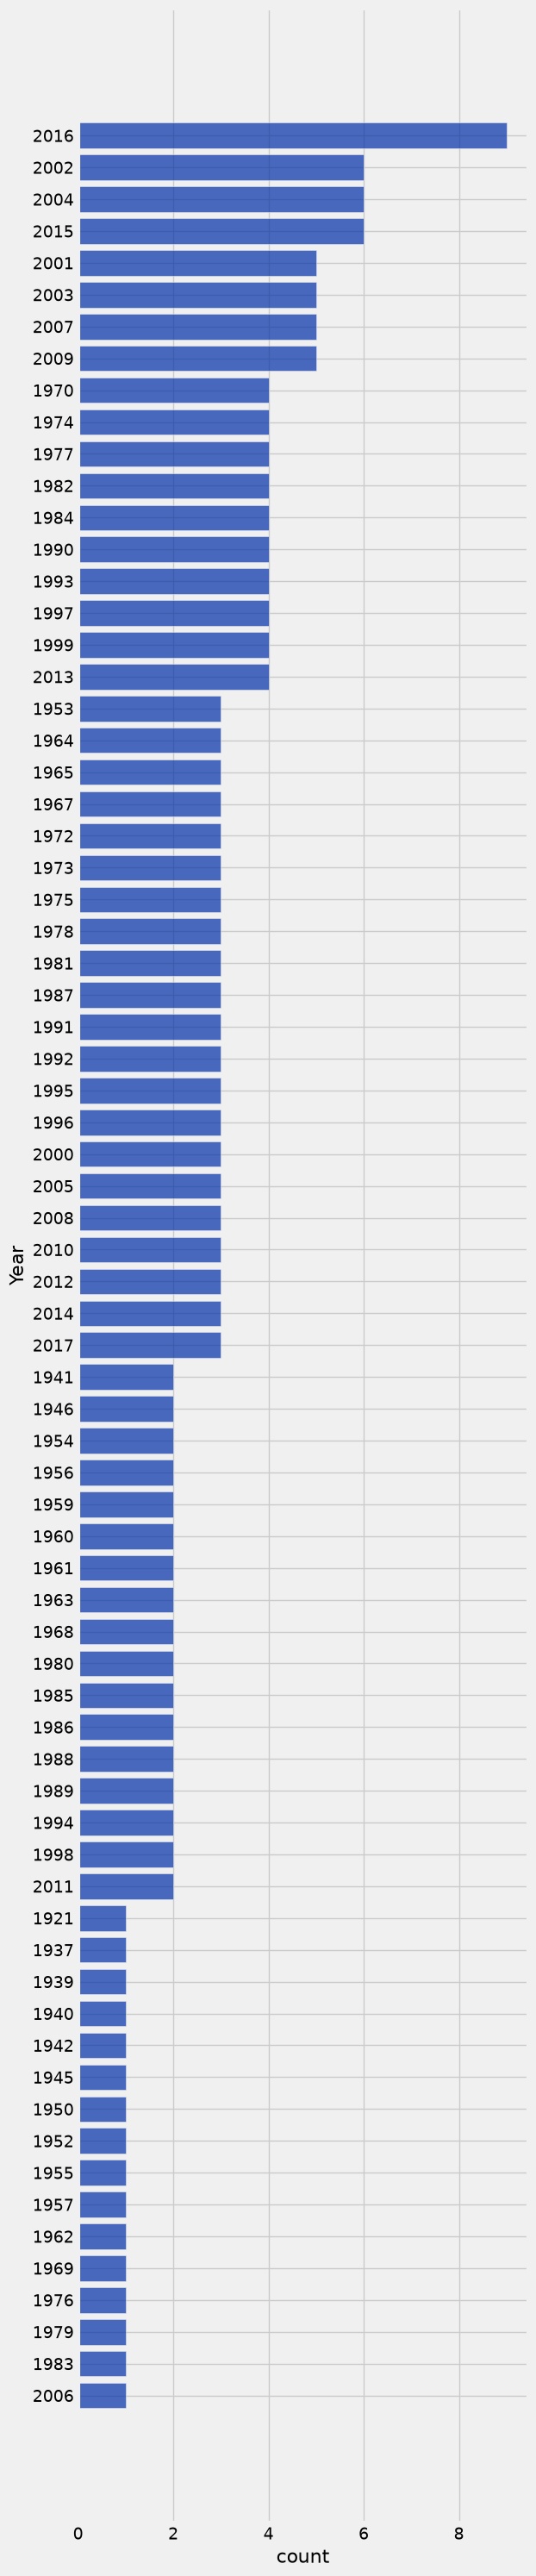

In [24]:
year_freq = top_movies.group('Year')
year_freq = year_freq.sort('count', descending = True)
year_freq.barh('Year', 'count')

# Binning
Lets put the movies into five-year bins and plot again.

In [25]:
# Generate 10 equally spaced bins, but it's not great for a variable like Year
auto_binned_movies = top_movies.bin('Year', bins = 10)
auto_binned_movies.show()

bin,Year count
1921,1
1930.6,3
1940.2,6
1949.8,13
1959.4,18
1969,26
1978.6,24
1988.2,28
1997.8,40
2007.4,41


In [26]:
# Use arange to create specific bins
max_year = max(top_movies.column('Year'))
min_year = min(top_movies.column('Year'))
print(min_year, max_year)

1921 2017


In [27]:
# Creates an array starting at 1921, ending at 2018, and counts by 9s
year_bins = np.arange(1921, 2018, 9)
year_bins

array([1921, 1930, 1939, 1948, 1957, 1966, 1975, 1984, 1993, 2002, 2011])

In [28]:
# Appears to have no movies released after 2011 because the last bin is always empty.
manual_binned_movies = top_movies.bin('Year', bins = year_bins)
manual_binned_movies.show()

bin,Year count
1921,1
1930,1
1939,8
1948,10
1957,16
1966,20
1975,22
1984,25
1993,30
2002,39


In [29]:
# We can fix it by making sure the last number incorporates our max year.
year_bins = np.arange(1921, 2021, 9)
manual_binned_movies = top_movies.bin('Year', bins = year_bins)
manual_binned_movies.show()


bin,Year count
1921,1
1930,1
1939,8
1948,10
1957,16
1966,20
1975,22
1984,25
1993,30
2002,37


In [30]:
year_bins

array([1921, 1930, 1939, 1948, 1957, 1966, 1975, 1984, 1993, 2002, 2011,
       2020])

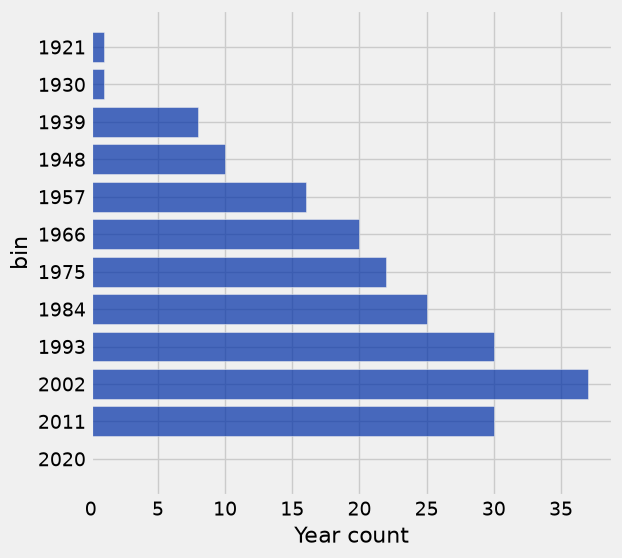

In [31]:
manual_binned_movies.barh('bin')

# Practice
Find reasonable bin sizes for adjusted gross. Aim for ten or so nonempty bins.
Bin the data and plot the resulting frequencies.

* Use min and max to find a good lower and upper bound for the bins.
* Experiment with bin sizes until you have about ten or so bins.
* Use the bin function create a new binned table.
* Call barh on the new table.

In [41]:
min_gross = min(top_movies.column('Gross (Adjusted)'))
max_gross = max(top_movies.column('Gross (Adjusted)'))
print("min : " + str(min_gross) + ", max: " + str(max_gross))

min : 338409100, max: 1796176700


In [ ]:
(1800000000 - 300000000)/10

1800000000

In [40]:
gross_bins = np.arange(300000000, 1900000000, 150000000)
gross_bins

array([ 300000000,  450000000,  600000000,  750000000,  900000000,
       1050000000, 1200000000, 1350000000, 1500000000, 1650000000,
       1800000000])

In [43]:
gross_binned = top_movies.bin('Gross (Adjusted)', bins = gross_bins)
gross_binned.show()


bin,Gross (Adjusted) count
300000000,98
450000000,62
600000000,18
750000000,11
900000000,3
1050000000,3
1200000000,3
1350000000,0
1500000000,1
1650000000,1


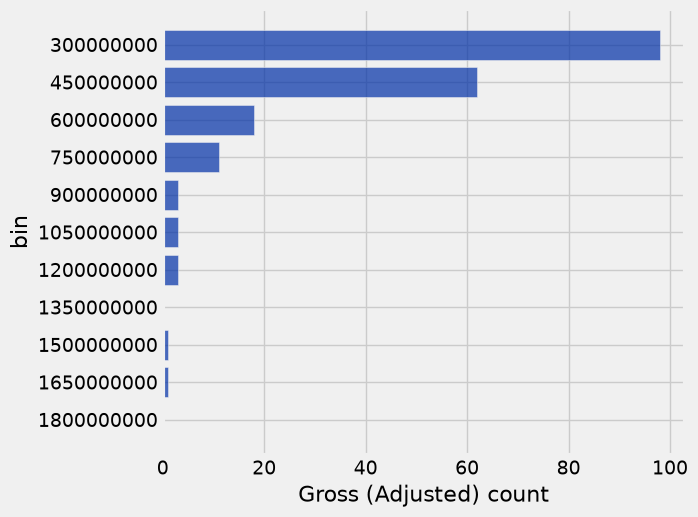

In [44]:
binned_gross_bar = gross_binned.barh('bin')

In [32]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937
